STEP 1: Load Dataset

In [18]:
import pandas as pd

# Load your dataset
df = pd.read_csv("student_data2.csv")

print(df.head())
print(df.info())
print(df.shape)

   cgpa  gender branch college_tier  internships_count  projects_count  \
0  8.56    Male    CSE       Tier 2                1.0             3.0   
1  8.08    Male    CSE       Tier 2                1.0             3.0   
2  7.69    Male    CSE       Tier 2                1.0             3.0   
3  8.71  Female    CSE       Tier 2                1.0             3.0   
4  9.93  Female    CSE       Tier 2                1.0             3.0   

   coding_skill_score  aptitude_score  communication_skill_score  \
0           84.706700       51.082983                  68.902831   
1           74.545943       43.276110                  75.508119   
2           71.775661       51.694109                  64.601532   
3           70.785801       76.035009                  60.559272   
4           56.987197       57.101626                 100.000000   

   github_repos  linkedin_connections  mock_interview_score  \
0           4.0                 165.0             55.312561   
1           5.0     

C:\Users\Administrator\AppData\Local\Temp\ipykernel_15244\2992654253.py:4: DtypeWarning: Columns (0: gender, 1: branch, 2: college_tier, 3: placement_status) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv("student_data2.csv")


STEP 2: Data Preprocessing

In [19]:
df.dropna(how='all', inplace=True)
df = pd.get_dummies(df, columns=['gender', 'branch', 'college_tier'], drop_first=True)
df['placement_status'] = df['placement_status'].map({
    'Not Placed': 0,
    'Placed': 1
})

In [20]:
# Check your actual distribution
print(df['placement_status'].value_counts())
print(df['placement_status'].value_counts(normalize=True))

placement_status
1    27593
0    23601
Name: count, dtype: int64
placement_status
1    0.538989
0    0.461011
Name: proportion, dtype: float64


PART 1: CLASSIFICATION (Placement Prediction)

In [21]:
X = df.drop(['salary_package_lpa', 'placement_status'], axis=1)
y = df['placement_status']

In [22]:
#Train-Test Split
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    shuffle=True,
    stratify=y
)

In [24]:
print(X_train.columns.tolist())

['cgpa', 'internships_count', 'projects_count', 'coding_skill_score', 'aptitude_score', 'communication_skill_score', 'github_repos', 'linkedin_connections', 'mock_interview_score', 'extracurricular_score', 'leadership_score', 'study_hours_per_day', 'certifications_count', 'gender_Male', 'branch_Civil', 'branch_ECE', 'branch_EEE', 'branch_IT', 'branch_Mechanical', 'college_tier_Tier 2', 'college_tier_Tier 3']


In [25]:
from sklearn.ensemble import RandomForestClassifier

clf = RandomForestClassifier(n_estimators=100, random_state=42)
clf.fit(X_train, y_train)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, ``N_t_R`` and ``N_t_L`` all refer to the weighted sum,if ``sample_weight`` is passed... versionadded:: 0.19",0.0
,"bootstrap bootstrap: bool, default=TrueWhether bootstrap samples are used when building trees. If False, thewhole dataset is used to build each tree.",True
,"oob_score oob_score: bool or callable, default=FalseWhether to use out-of-bag samples to estimate the generalization score.By default, :func:`~sklearn.metrics.accuracy_score` is used.Provide a callable with signature `metric

In [26]:
# For Random Forest
import pandas as pd
feature_importance = pd.DataFrame({
    'feature': X_train.columns,
    'importance': clf.feature_importances_
}).sort_values('importance', ascending=False)

print("Top 10 features:")
print(feature_importance.head(10))

# If one feature dominates (>50% importance), investigate it

Top 10 features:
                      feature  importance
1           internships_count    0.708780
12       certifications_count    0.073988
3          coding_skill_score    0.021292
8        mock_interview_score    0.020947
4              aptitude_score    0.020415
5   communication_skill_score    0.020190
9       extracurricular_score    0.019946
10           leadership_score    0.019792
0                        cgpa    0.019127
7        linkedin_connections    0.018798


In [27]:
from sklearn.model_selection import cross_val_score

cv_scores = cross_val_score(RandomForestClassifier(), X_train, y_train, cv=5)
print(f"CV scores: {cv_scores}")
print(f"CV mean: {cv_scores.mean():.3f} (+/- {cv_scores.std():.3f})")
# If std is very small (<0.01), might be too good

CV scores: [0.97655964 0.97399585 0.97570504 0.97839092 0.97790258]
CV mean: 0.977 (+/- 0.002)


In [ ]:
from xgboost import XGBClassifier
xgb = XGBClassifier(
    n_estimators=300,
    learning_rate=0.1,
    max_depth=3,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42
)

xgb.fit(X_train, y_train)

,"objective objective: typing.Union[str, xgboost.sklearn._SklObjWProto, typing.Callable[[typing.Any, typing.Any], typing.Tuple[numpy.ndarray, numpy.ndarray]], NoneType]Specify the learning task and the corresponding learning objective or a customobjective function to be used.For custom objective, see :doc:`/tutorials/custom_metric_obj` and:ref:`custom-obj-metric` for more information, along with the end note forfunction signatures.",'binary:logistic'
,"base_score base_score: typing.Union[float, typing.List[float], NoneType]The initial prediction score of all instances, global bias.",None
,booster,None
,"callbacks callbacks: typing.Optional[typing.List[xgboost.callback.TrainingCallback]]List of callback functions that are applied at end of each iteration.It is possible to use predefined callbacks by using:ref:`Callback API `... note:: States in callback are not preserved during training, which means callback objects can not be reused for multiple training sessions without reinitialization or deepcopy... code-block:: python for params in parameters_grid: # be sure to (re)initialize the callbacks before each run callbacks = [xgb.callback.LearningRateScheduler(custom_rates)] reg = xgboost.XGBRegressor(**params, callbacks=callbacks) reg.fit(X, y)",None
,colsample_bylevel colsample_bylevel: typing.Optional[float]Subsample ratio of columns for each level.,None
,colsample_bynode colsample_bynode: typing.Optional[float]Subsample ratio of columns for each split.,None
,colsample_bytree colsample_bytree: typing.Optional[float]Subsample ratio of columns when constructing each tree.,0.8
,"device device: typing.Optional[str].. versionadded:: 2.0.0Device ordinal, available options are `cpu`, `cuda`, and `gpu`.",None
,"early_stopping_rounds early_stopping_rounds: typing.Optional[int].. versionadded:: 1.6.0- Activates early stopping. Validation metric needs to improve at least once in every **early_stopping_rounds** round(s) to continue training. Requires at least one item in **eval_set** in :py:meth:`fit`.- If early stopping occurs, the model will have two additional attributes: :py:attr:`best_score` and :py:attr:`best_iteration`. These are used by the :py:meth:`predict` and :py:meth:`apply` methods to determine the optimal number of trees during inference. If users want to access the full model (including trees built after early stopping), they can specify the `iteration_range` in these inference methods. In addition, other utilities like model plotting can also use the entire model.- If you prefer to discard the trees after `best_iteration`, consider using the callback function :py:class:`xgboost.callback.EarlyStopping`.- If there's more than one item in **eval_set**, the last entry will be used for early stopping. If there's more than one metric in **eval_metric**, the last metric will be used for early stopping.",None
,enable_categorical enable_categorical: boolSee the same parameter of :py:class:`DMatrix` for details.,False
,"eval_metric eval_metric: typing.Union[str, typing.List[typing.Union[str, typing.Callable]], typing.Callable, NoneType].. versionadded:: 1.6.0Metric used for monitoring the training result and early stopping. It can be astring or list of strings as names of predefined metric in XGBoost (See:doc:`/parameter`), one of the metrics in :py:mod:`sklearn.metrics`, or anyother user defined metric that looks like `sklearn.metrics`.If custom objective is also provided, then custom metric should implement thecorresponding reverse link function.Unlike the `scoring` parameter commonly used in scikit-learn, when a callableobject is provided, it's assumed to be a cost function and by default XGBoostwill minimize the result during early stopping.For advanced usage on Early stopping like directly choosing to maximize insteadof minimize, see :py:obj:`xgboost.callback.EarlyStopping`.See :doc:`/tutorials/custom_metric_obj` and :ref:`custom-obj-metric` for moreinformation... code-block:: python from sklearn.datasets import load_diabetes f

In [29]:
#Predictions
y_pred_clf = clf.predict(X_test)
y_pred_xgb = xgb.predict(X_test)

In [30]:
#Evaluation
from sklearn.metrics import accuracy_score, classification_report

print("Accuracy (Random Forest):", accuracy_score(y_test, y_pred_clf))
print("Classification Report (Random Forest):")
print(classification_report(y_test, y_pred_clf))

print("Accuracy (XGBoost):", accuracy_score(y_test, y_pred_xgb))
print("Classification Report (XGBoost):")
print(classification_report(y_test, y_pred_xgb))

Accuracy (Random Forest): 0.9738255689032133
Classification Report (Random Forest):
              precision    recall  f1-score   support

           0       0.96      0.98      0.97      4720
           1       0.98      0.97      0.98      5519

    accuracy                           0.97     10239
   macro avg       0.97      0.97      0.97     10239
weighted avg       0.97      0.97      0.97     10239

Accuracy (XGBoost): 0.9771462056841489
Classification Report (XGBoost):
              precision    recall  f1-score   support

           0       0.98      0.97      0.98      4720
           1       0.97      0.98      0.98      5519

    accuracy                           0.98     10239
   macro avg       0.98      0.98      0.98     10239
weighted avg       0.98      0.98      0.98     10239



In [31]:
import pickle

# After training your models
with open('random_forest_classifier.pkl', 'wb') as f:
    pickle.dump(clf, f)

with open('xgb_classifier.vpkl', 'wb') as f:
    pickle.dump(xgb, f)

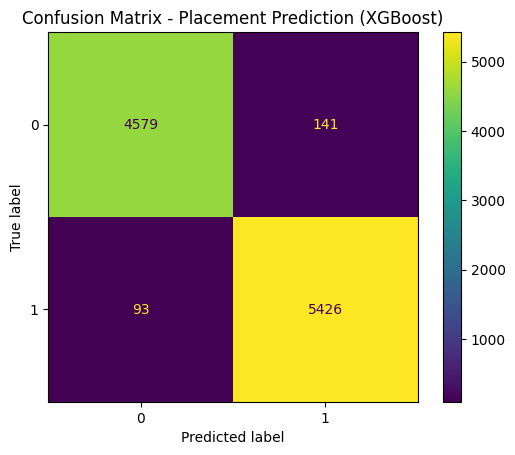

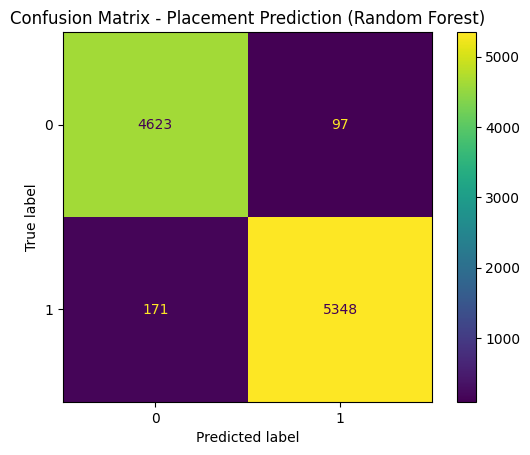

In [32]:
#Confusion Matrix Plot
import matplotlib.pyplot as plt
from sklearn.metrics import ConfusionMatrixDisplay

ConfusionMatrixDisplay.from_estimator(xgb, X_test, y_test)
plt.title("Confusion Matrix - Placement Prediction (XGBoost)")
plt.show()

ConfusionMatrixDisplay.from_estimator(clf, X_test, y_test)
plt.title("Confusion Matrix - Placement Prediction (Random Forest)")
plt.show()



Placement rate by internship count:
placement_status         0        1
internships_count                  
0.0                0.00000  1.00000
1.0                1.00000  0.00000
2.0                0.61481  0.38519
3.0                0.00000  1.00000
4.0                0.00000  1.00000
5.0                0.00000  1.00000
6.0                0.00000  1.00000
7.0                0.00000  1.00000
8.0                0.00000  1.00000


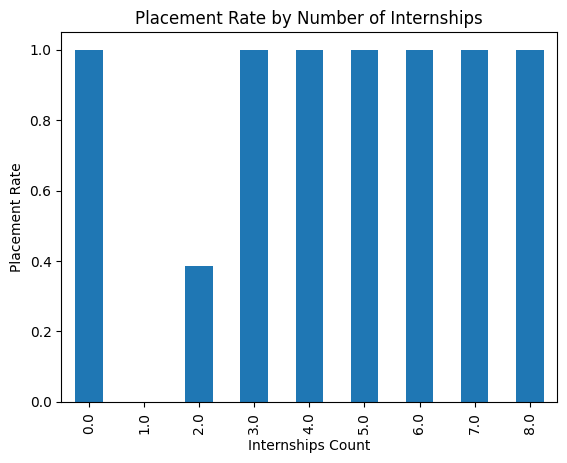

In [33]:
# Check the internship-placement relationship
internship_placement = pd.crosstab(df['internships_count'], df['placement_status'], normalize='index')
print("Placement rate by internship count:")
print(internship_placement)

# Visualize
import matplotlib.pyplot as plt
internship_placement[1].plot(kind='bar')
plt.title('Placement Rate by Number of Internships')
plt.xlabel('Internships Count')
plt.ylabel('Placement Rate')
plt.show()

PART 2: REGRESSION (Salary Prediction)

In [34]:
# Filter only placed students
df_reg = df[df['placement_status'] == 1]  # 1 = Placed

In [35]:
#Features & Target
X_reg = df_reg.drop(['salary_package_lpa', 'placement_status'], axis=1)
y_reg = df_reg['salary_package_lpa']

In [36]:
#Train-Test Split
X_train_r, X_test_r, y_train_r, y_test_r = train_test_split(
    X_reg, y_reg,
    test_size=0.2,
    random_state=42,
    shuffle=True,
)

In [37]:
#Model: Random Forest Regressor
from sklearn.ensemble import RandomForestRegressor

reg = RandomForestRegressor(n_estimators=100, random_state=42)
reg.fit(X_train_r, y_train_r)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""squared_error"", ""absolute_error"", ""friedman_mse"", ""poisson""}, default=""squared_error""The function to measure the quality of a split. Supported criteriaare ""squared_error"" for the mean squared error, which is equal tovariance reduction as feature selection criterion and minimizes the L2loss using the mean of each terminal node, ""friedman_mse"", which usesmean squared error with Friedman's improvement score for potentialsplits, ""absolute_error"" for the mean absolute error, which minimizesthe L1 loss using the median of each terminal node, and ""poisson"" whichuses reduction in Poisson deviance to find splits.Training using ""absolute_error"" is significantly slowerthan when using ""squared_error""... versionadded:: 0.18 Mean Absolute Error (MAE) criterion... versionadded:: 1.0 Poisson criterion.",'squared_error'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=1.0The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None or 1.0, then `max_features=n_features`... note:: The default of 1.0 is equivalent to bagged trees and more randomness can be achieved by setting smaller values, e.g. 0.3... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to 1.0.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",1.0
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsample

In [38]:
#Predictions
y_pred_r = reg.predict(X_test_r)

In [39]:
#Evaluation
from sklearn.metrics import mean_absolute_error, r2_score

print("MAE:", mean_absolute_error(y_test_r, y_pred_r))
print("R2 Score:", r2_score(y_test_r, y_pred_r))

MAE: 0.8274252581989492
R2 Score: 0.6205173500273716


In [40]:
import pickle
    
with open('random_forest_regressor.pkl', 'wb') as f:
    pickle.dump(reg, f)
    

Visualisation

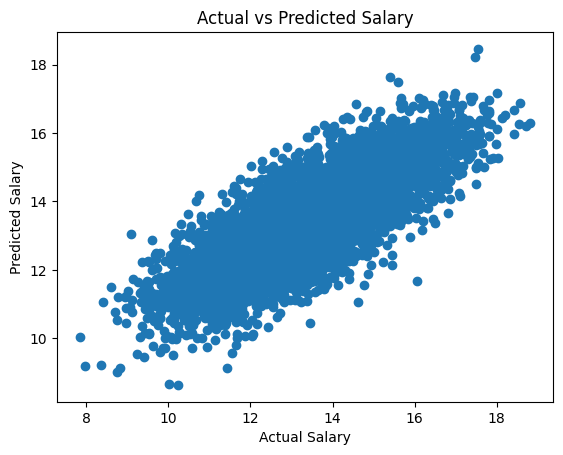

In [41]:
#Actual vs Predicted Graph
import matplotlib.pyplot as plt

plt.scatter(y_test_r, y_pred_r)
plt.xlabel("Actual Salary")
plt.ylabel("Predicted Salary")
plt.title("Actual vs Predicted Salary")
plt.show()

Index(['cgpa', 'internships_count', 'projects_count', 'coding_skill_score',
       'aptitude_score', 'communication_skill_score', 'github_repos',
       'linkedin_connections', 'mock_interview_score', 'extracurricular_score',
       'leadership_score', 'study_hours_per_day', 'certifications_count',
       'gender_Male', 'branch_Civil', 'branch_ECE', 'branch_EEE', 'branch_IT',
       'branch_Mechanical', 'college_tier_Tier 2', 'college_tier_Tier 3'],
      dtype='str') [0.25977144 0.24165463 0.01373914 0.22084126 0.03216037 0.03192149
 0.01514676 0.03009693 0.03154545 0.03165479 0.03063208 0.02703733
 0.01124676 0.00361113 0.00224522 0.00277928 0.00219694 0.00295595
 0.00224882 0.00341967 0.00309455]


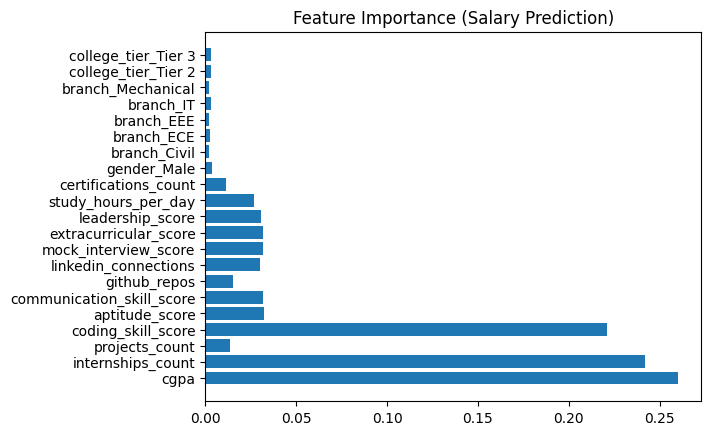

In [42]:
# Feature Importance Graph
import pandas as pd
import matplotlib.pyplot as plt

importances = reg.feature_importances_
features = X_reg.columns
print(features, importances)
plt.barh(features, importances)
plt.title("Feature Importance (Salary Prediction)")
plt.show()

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# Load your dataset
df = pd.read_csv("student_data2.csv", low_memory=False)

# Clean column names (remove any whitespace)
df.columns = df.columns.str.strip()

# Basic data cleaning
df = df.dropna()  # Remove missing values

# Map placement status for better visualization
df['placement_status'] = df['placement_status'].map({
    'Not Placed': 0,
    'Placed': 1
})

# ============================================
# BOX PLOT 1: CGPA Distribution by Placement Status
# ============================================
plt.figure(figsize=(10, 6))
sns.boxplot(data=df, x='placement_status', y='cgpa', palette=['lightcoral', 'lightgreen'])
plt.title('CGPA Distribution by Placement Status', fontsize=14, fontweight='bold')
plt.xlabel('Placement Status (0 = Not Placed, 1 = Placed)', fontsize=12)
plt.ylabel('CGPA (0-10 Scale)', fontsize=12)
plt.xticks([0, 1], ['Not Placed', 'Placed'])
plt.grid(True, alpha=0.3)
plt.show()

# ============================================
# BOX PLOT 2: Salary Package by College Tier
# ============================================
# Filter only placed students for salary analysis
placed_df = df[df['placement_status'] == 1].copy()

plt.figure(figsize=(10, 6))
sns.boxplot(data=placed_df, x='college_tier', y='salary_package_lpa', palette='Set2')
plt.title('Salary Package Distribution by College Tier (Placed Students)', fontsize=14, fontweight='bold')
plt.xlabel('College Tier', fontsize=12)
plt.ylabel('Salary Package (LPA)', fontsize=12)
plt.grid(True, alpha=0.3)
plt.show()

# ============================================
# BOX PLOT 3: Internships Count vs Salary
# ============================================
plt.figure(figsize=(12, 6))
sns.boxplot(data=placed_df, x='internships_count', y='salary_package_lpa', palette='viridis')
plt.title('Salary Distribution by Number of Internships', fontsize=14, fontweight='bold')
plt.xlabel('Number of Internships', fontsize=12)
plt.ylabel('Salary Package (LPA)', fontsize=12)
plt.grid(True, alpha=0.3)
plt.show()

# ============================================
# BOX PLOT 4: Multiple Skills Box Plot
# ============================================
# Select skill columns
skill_columns = ['coding_skill_score', 'aptitude_score', 'communication_skill_score', 
                 'mock_interview_score', 'extracurricular_score', 'leadership_score']

# Reshape data for box plot
skills_melted = df[skill_columns + ['placement_status']].melt(
    id_vars=['placement_status'], 
    var_name='Skill', 
    value_name='Score'
)

plt.figure(figsize=(14, 7))
sns.boxplot(data=skills_melted, x='Skill', y='Score', hue='placement_status', palette=['lightcoral', 'lightgreen'])
plt.title('Skill Score Distribution by Placement Status', fontsize=14, fontweight='bold')
plt.xlabel('Skill Type', fontsize=12)
plt.ylabel('Score (0-100)', fontsize=12)
plt.xticks(rotation=45, ha='right')
plt.legend(title='Placement Status', labels=['Not Placed', 'Placed'])
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# ============================================
# BOX PLOT 5: Study Hours vs Placement
# ============================================
plt.figure(figsize=(10, 6))
sns.boxplot(data=df, x='placement_status', y='study_hours_per_day', palette=['lightcoral', 'lightgreen'])
plt.title('Study Hours Distribution by Placement Status', fontsize=14, fontweight='bold')
plt.xlabel('Placement Status', fontsize=12)
plt.ylabel('Study Hours per Day', fontsize=12)
plt.xticks([0, 1], ['Not Placed', 'Placed'])
plt.grid(True, alpha=0.3)
plt.show()

# ============================================
# BOX PLOT 6: CGPA by Branch (Only Placed Students)
# ============================================
plt.figure(figsize=(12, 6))
sns.boxplot(data=df, x='branch', y='cgpa', hue='placement_status', palette=['lightcoral', 'lightgreen'])
plt.title('CGPA Distribution by Branch and Placement Status', fontsize=14, fontweight='bold')
plt.xlabel('Engineering Branch', fontsize=12)
plt.ylabel('CGPA', fontsize=12)
plt.xticks(rotation=45, ha='right')
plt.legend(title='Placement Status', labels=['Not Placed', 'Placed'])
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# ============================================
# BOX PLOT 7: Projects Count vs Salary
# ============================================
plt.figure(figsize=(12, 6))
sns.boxplot(data=placed_df, x='projects_count', y='salary_package_lpa', palette='coolwarm')
plt.title('Salary Distribution by Number of Projects', fontsize=14, fontweight='bold')
plt.xlabel('Number of Projects', fontsize=12)
plt.ylabel('Salary Package (LPA)', fontsize=12)
plt.grid(True, alpha=0.3)
plt.show()

# ============================================
# BOX PLOT 8: LinkedIn Connections vs Placement
# ============================================
plt.figure(figsize=(10, 6))
sns.boxplot(data=df, x='placement_status', y='linkedin_connections', palette=['lightcoral', 'lightgreen'])
plt.title('LinkedIn Connections Distribution by Placement Status', fontsize=14, fontweight='bold')
plt.xlabel('Placement Status', fontsize=12)
plt.ylabel('LinkedIn Connections', fontsize=12)
plt.xticks([0, 1], ['Not Placed', 'Placed'])
plt.grid(True, alpha=0.3)
# Add log scale if data is skewed
plt.yscale('log')
plt.ylabel('LinkedIn Connections (Log Scale)', fontsize=12)
plt.show()

# ============================================
# BOX PLOT 9: Certifications vs Placement
# ============================================
plt.figure(figsize=(10, 6))
sns.boxplot(data=df, x='placement_status', y='certifications_count', palette=['lightcoral', 'lightgreen'])
plt.title('Certifications Count Distribution by Placement Status', fontsize=14, fontweight='bold')
plt.xlabel('Placement Status', fontsize=12)
plt.ylabel('Number of Certifications', fontsize=12)
plt.xticks([0, 1], ['Not Placed', 'Placed'])
plt.grid(True, alpha=0.3)
plt.show()

# ============================================
# BOX PLOT 10: All Numeric Features Overview
# ============================================
# Select numeric columns
numeric_cols = df.select_dtypes(include=[np.number]).columns.tolist()
# Remove target variables
numeric_cols = [col for col in numeric_cols if col not in ['placement_status', 'salary_package_lpa']]

# Create subplots
fig, axes = plt.subplots(4, 4, figsize=(16, 16))
axes = axes.flatten()

for idx, col in enumerate(numeric_cols[:16]):  # Plot first 16 numeric columns
    sns.boxplot(data=df, x='placement_status', y=col, ax=axes[idx], palette=['lightcoral', 'lightgreen'])
    axes[idx].set_title(f'{col}', fontsize=10)
    axes[idx].set_xlabel('')
    axes[idx].set_xticks([0, 1])
    axes[idx].set_xticklabels(['Not Placed', 'Placed'], fontsize=8)
    axes[idx].grid(True, alpha=0.3)

# Remove empty subplots
for idx in range(len(numeric_cols[:16]), len(axes)):
    fig.delaxes(axes[idx])

plt.suptitle('Distribution of Key Features by Placement Status', fontsize=16, fontweight='bold')
plt.tight_layout()
plt.show()

# ============================================
# BONUS: Box Plot with Statistical Annotations
# ============================================
def boxplot_with_stats(data, x_col, y_col, title):
    """Create box plot with median and quartile annotations"""
    fig, ax = plt.subplots(figsize=(10, 6))
    
    # Create box plot
    sns.boxplot(data=data, x=x_col, y=y_col, ax=ax, palette='Set3')
    
    # Calculate statistics for each group
    groups = data[x_col].unique()
    for i, group in enumerate(groups):
        group_data = data[data[x_col] == group][y_col].dropna()
        median = group_data.median()
        q1 = group_data.quantile(0.25)
        q3 = group_data.quantile(0.75)
        
        # Add text annotations
        ax.text(i, median, f' Median: {median:.2f}', 
                ha='left', va='center', fontsize=10, fontweight='bold',
                bbox=dict(boxstyle='round,pad=0.3', facecolor='yellow', alpha=0.7))
        ax.text(i, q1, f' Q1: {q1:.2f}', ha='left', va='bottom', fontsize=8, alpha=0.7)
        ax.text(i, q3, f' Q3: {q3:.2f}', ha='left', va='top', fontsize=8, alpha=0.7)
    
    ax.set_title(title, fontsize=14, fontweight='bold')
    ax.set_xlabel(x_col, fontsize=12)
    ax.set_ylabel(y_col, fontsize=12)
    ax.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()

# Example usage
boxplot_with_stats(placed_df, 'internships_count', 'salary_package_lpa', 
                   'Salary Distribution by Internship Count with Statistics')

# ============================================
# Advanced: Subplot Grid for Key Comparisons
# ============================================
fig, axes = plt.subplots(2, 3, figsize=(15, 10))

# Plot 1: CGPA
sns.boxplot(data=df, x='placement_status', y='cgpa', ax=axes[0,0], palette='Set1')
axes[0,0].set_title('CGPA')
axes[0,0].set_xticklabels(['Not Placed', 'Placed'])

# Plot 2: Internships
sns.boxplot(data=df, x='placement_status', y='internships_count', ax=axes[0,1], palette='Set1')
axes[0,1].set_title('Internships Count')
axes[0,1].set_xticklabels(['Not Placed', 'Placed'])

# Plot 3: Coding Skills
sns.boxplot(data=df, x='placement_status', y='coding_skill_score', ax=axes[0,2], palette='Set1')
axes[0,2].set_title('Coding Skill Score')
axes[0,2].set_xticklabels(['Not Placed', 'Placed'])

# Plot 4: Certifications
sns.boxplot(data=df, x='placement_status', y='certifications_count', ax=axes[1,0], palette='Set1')
axes[1,0].set_title('Certifications Count')
axes[1,0].set_xticklabels(['Not Placed', 'Placed'])

# Plot 5: Projects
sns.boxplot(data=df, x='placement_status', y='projects_count', ax=axes[1,1], palette='Set1')
axes[1,1].set_title('Projects Count')
axes[1,1].set_xticklabels(['Not Placed', 'Placed'])

# Plot 6: Study Hours
sns.boxplot(data=df, x='placement_status', y='study_hours_per_day', ax=axes[1,2], palette='Set1')
axes[1,2].set_title('Study Hours per Day')
axes[1,2].set_xticklabels(['Not Placed', 'Placed'])

plt.suptitle('Key Feature Comparison: Placed vs Not Placed Students', fontsize=16, fontweight='bold')
plt.tight_layout()
plt.show()